# TAE-IA · Module 6 · L02 — Prompting Mastery: Text-to-Image

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L02 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisite** | L01 completed — SD 1.5 weights cached in Drive |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Build structured prompts using the 5-layer anatomy (subject, setting, style, quality, reference)
- [ ] Use negative prompts to reduce specific artifacts
- [ ] Load and compare community fine-tuned models from Hugging Face Hub
- [ ] Save outputs with systematic filenames for reproducible analysis

## Before you start
- L01 completed: SD 1.5 weights should already be cached in `TAE_IA_M6/models` on your Drive
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed. SD 1.5 weights load from cache — no re-download needed if you completed L01.

In [17]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model cache: /content/drive/MyDrive/TAE_IA_M6/models
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128


In [18]:
# ================================================================
# Install dependencies for L02
# ================================================================
!pip install diffusers transformers accelerate -q

import diffusers
print(f'diffusers {diffusers.__version__}')

diffusers 0.40.0


## Cell 0b — HuggingFace Login (needed every new Colab session)

> Colab wipes your login state every time you get a fresh runtime, even though your `HF_TOKEN` secret itself stays saved in your account. This cell re-authenticates using that saved secret so the gated SD 1.5 checkpoint below can download. If this is your first time, see **L00 Cell 4** for how to create the token and accept the model license.

In [19]:
# ================================================================
# Ensure HuggingFace login -- needed every new Colab session
# ================================================================
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Already logged in to HuggingFace as: joalmurilloor


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### Prompt anatomy — the 5 layers

A prompt is not a sentence you describe to a friend — it is a **stack of descriptors** that the CLIP encoder converts into a vector. Each layer adds a different kind of information:

| Layer | What it controls | Example |
|---|---|---|
| **Subject** | What is in the image | `a red fox sitting on a rock` |
| **Setting** | Location, time, atmosphere | `in a snowy forest, winter dawn` |
| **Style** | Artistic medium or movement | `oil painting, impressionist` |
| **Quality** | Technical sharpness and detail | `8k, highly detailed, sharp focus` |
| **Reference** | Artist or aesthetic anchor | `by Ivan Shishkin` |

**Word order matters slightly:** CLIP gives marginally more attention weight to tokens closer to the beginning of the prompt. Put your most important descriptors first.

**Token limit:** CLIP truncates at 77 tokens. A word is roughly 1 token; punctuation and spaces add tokens. Prompts longer than ~60 words risk having the end silently ignored.

### Negative prompts

A negative prompt tells the model what to *move away from* during denoising. It works because Classifier-Free Guidance (CFG) computes:

```
final_output ≈ negative_output + guidance_scale × (positive_output − negative_output)
```

By default, `negative_output` uses an empty string embedding ("unconditioned"). Replacing it with a real negative prompt embedding makes the model actively steer away from those concepts.

Common starting negative prompt:
```
blurry, low quality, deformed, extra limbs, extra fingers, watermark, text, bad anatomy, cropped
```

### Community models

The Hugging Face Hub hosts thousands of fine-tuned SD 1.5 variants. They are loaded with the **exact same code** as the base model — only the model ID changes. The weights are cached to Drive on first download.

### Connection to L01

You already know how to load a pipeline and the effect of `num_inference_steps` and `guidance_scale`. This lesson focuses on the content of the prompt itself — the same pipeline, more controlled inputs.

---

## Part 2 — Lab

### Section 2.1 — Load the pipeline

SD 1.5 loads from Drive cache — should be fast.

In [20]:
# Section 2.1 — Load pipeline and output helper
from diffusers import StableDiffusionPipeline
import torch, os, time
import matplotlib.pyplot as plt

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")
print("Pipeline ready.")

# Helper: save image with a systematic filename
OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L02_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_img(img, prompt_id, seed=SEED, steps=25, cfg=7.5):
    fname = f"p{prompt_id:02d}_s{seed}_st{steps}_cfg{cfg:.0f}.png"
    img.save(os.path.join(OUTPUT_DIR, fname))
    return fname

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline ready.


### Section 2.2 — Prompt structure comparison grid

Same subject, 4 prompts with progressively more layers. Same seed throughout so the only variable is the prompt.

  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 1 done  → p01_s42_st25_cfg8.png


  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 2 done  → p02_s42_st25_cfg8.png


  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 3 done  → p03_s42_st25_cfg8.png


  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 4 done  → p04_s42_st25_cfg8.png


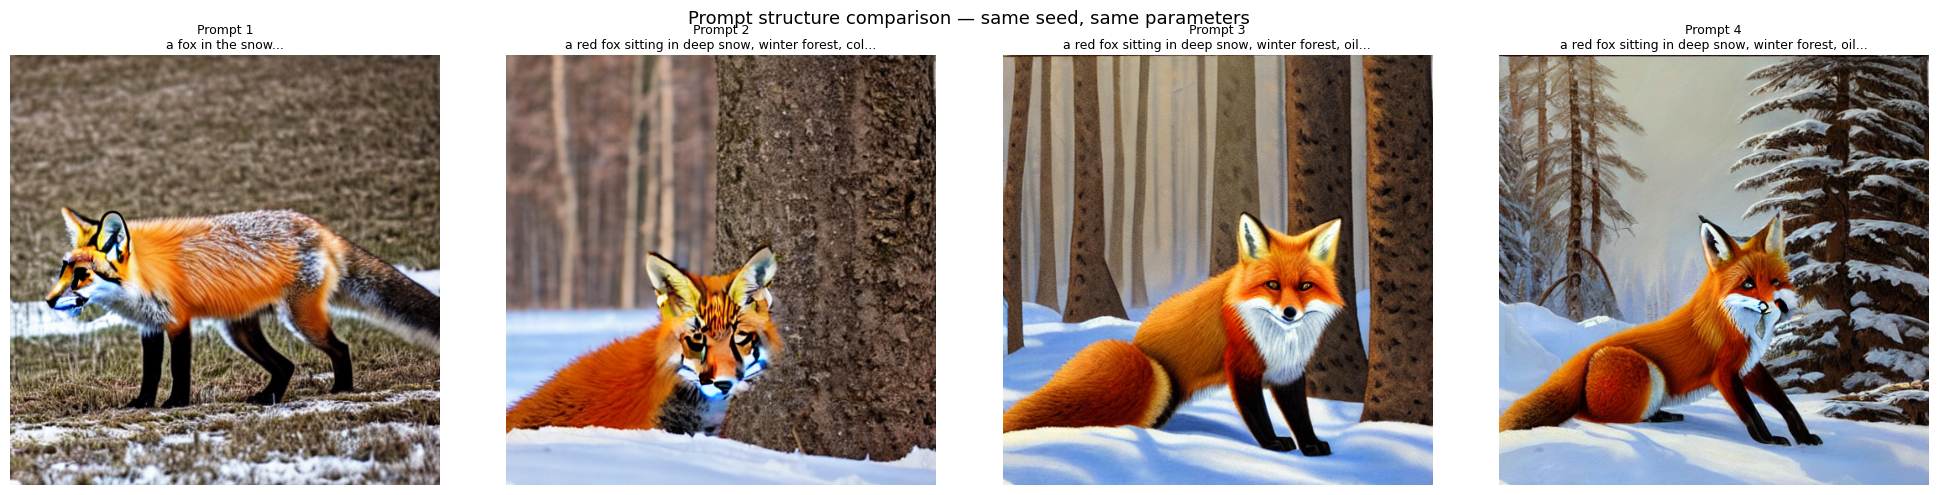

In [21]:
# Section 2.2 — 4-prompt comparison grid
STEPS = 25
CFG   = 7.5

prompts = [
    (1, "a fox in the snow"),
    (2, "a red fox sitting in deep snow, winter forest, cold morning light"),
    (3, "a red fox sitting in deep snow, winter forest, oil painting, detailed fur texture, soft morning light"),
    (4, "a red fox sitting in deep snow, winter forest, oil painting by Ivan Shishkin, "
        "detailed fur texture, soft morning light, artstation trending, 8k resolution"),
]

images = []
for pid, prompt in prompts:
    img = pipe(prompt, num_inference_steps=STEPS, guidance_scale=CFG, generator=gen()).images[0]
    fname = save_img(img, pid)
    images.append((pid, prompt[:50] + "...", img))
    print(f"Prompt {pid} done  → {fname}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (pid, label, img) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(f"Prompt {pid}\n{label}", fontsize=9, wrap=True)
    ax.axis('off')
plt.suptitle("Prompt structure comparison — same seed, same parameters", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_prompt_structure.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which layer (setting, style, quality, artist) changed the image most noticeably?
- Did adding the artist reference change the composition or just the style?

- **Most impactful layer**: The **Style** layer caused the most dramatic visual transformation (switching from a realistic photo in Prompt 2 to an oil painting in Prompt 3), completely changing the rendering medium, textures, and lighting.
- **Artist reference impact**: Adding the artist reference primarily refined the **artistic style and background details** (rendering snow-laden pine branches and classic landscape brushwork) rather than altering the core composition, which maintained the fox seated in deep snow.

### Section 2.3 — Negative prompts

Run the same rich prompt (Prompt 4) with and without a negative prompt. Then progressively expand the negative prompt to target specific artifacts you see.

  0%|          | 0/25 [00:00<?, ?it/s]

Negative 'none' done


  0%|          | 0/25 [00:00<?, ?it/s]

Negative 'basic' done


  0%|          | 0/25 [00:00<?, ?it/s]

Negative 'anatomy' done


  0%|          | 0/25 [00:00<?, ?it/s]

Negative 'extended' done


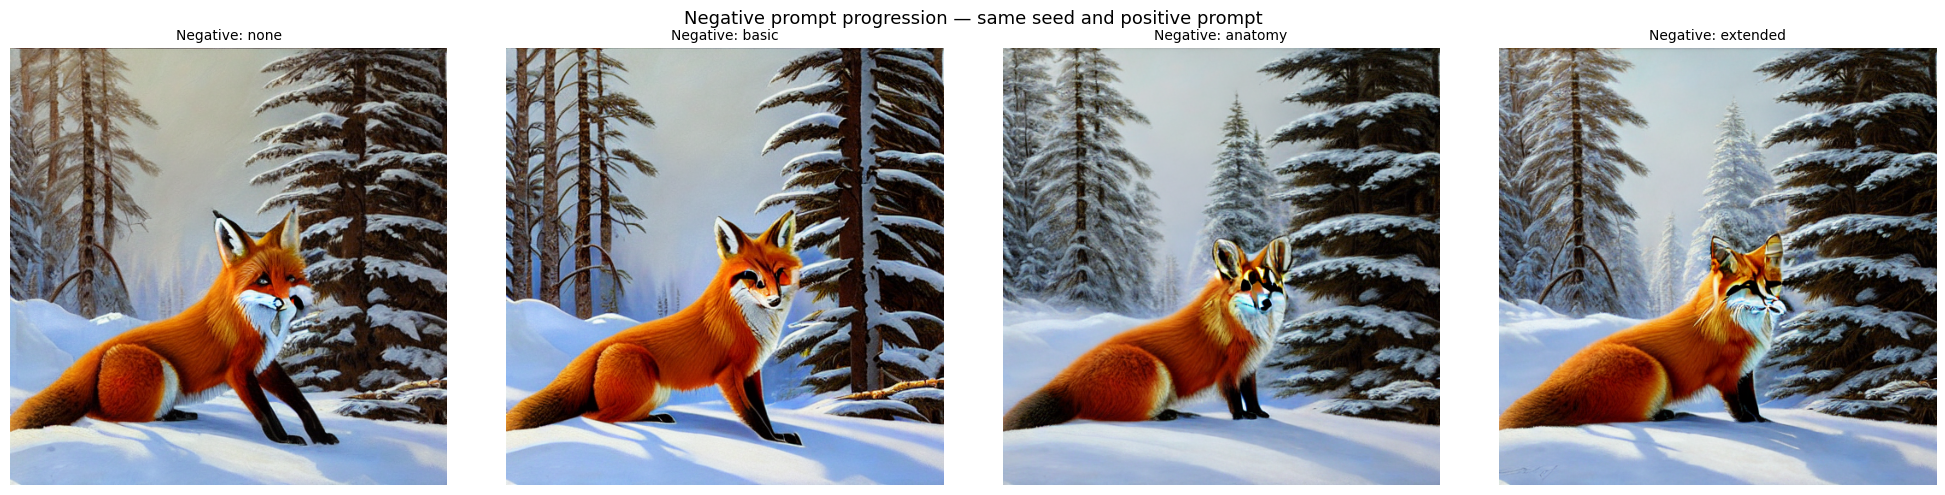

In [22]:
# Section 2.3 — Negative prompt comparison
rich_prompt = ("a red fox sitting in deep snow, winter forest, oil painting by Ivan Shishkin, "
               "detailed fur texture, soft morning light, artstation trending, 8k resolution")

negative_prompts = [
    ("none",     None),
    ("basic",    "blurry, low quality, watermark, text"),
    ("anatomy",  "blurry, low quality, watermark, text, deformed, extra limbs, bad anatomy"),
    ("extended", "blurry, low quality, watermark, text, deformed, extra limbs, bad anatomy, "
                 "poorly drawn, jpeg artifacts, cropped, worst quality, low resolution"),
]

neg_images = []
for label, neg in negative_prompts:
    img = pipe(
        rich_prompt,
        negative_prompt=neg,
        num_inference_steps=STEPS,
        guidance_scale=CFG,
        generator=gen()
    ).images[0]
    neg_images.append((label, img))
    img.save(os.path.join(OUTPUT_DIR, f"neg_{label}.png"))
    print(f"Negative '{label}' done")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, img) in zip(axes, neg_images):
    ax.imshow(img)
    ax.set_title(f"Negative: {label}", fontsize=10)
    ax.axis('off')
plt.suptitle("Negative prompt progression — same seed and positive prompt", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_negative_prompts.png"), dpi=100)
plt.show()

**What do you observe?**  
- Did the negative prompt fix a specific artifact, or did it change the image more broadly?
- Was there a point of diminishing returns (longer negative = not much better)?

- **Artifacts vs. Broad changes**: The negative prompt primarily fixed **specific anatomical artifacts** (improving paw definition, facial symmetry, and muzzle proportions) while subtly enhancing overall scene clarity and contrast in the background snow and trees.
- **Diminishing returns**: **Yes**, diminishing returns occurred after `Negative: anatomy`. Moving from `anatomy` to `extended` produced almost no visible difference, showing that stacking extensive negative tokens yields minimal gains once the core artifacts are resolved.

### Section 2.4 — Try a community model

Load DreamShaper (a popular SD 1.5 fine-tune) and run the same prompt. First download is ~2 GB to Drive — subsequent runs are instant.

VRAM freed. Available: 12.9 GB


model_index.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DreamShaper loaded.


  0%|          | 0/25 [00:00<?, ?it/s]

Generated with DreamShaper.


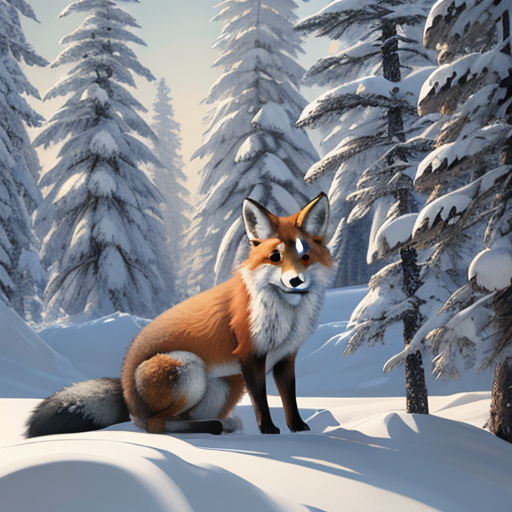

In [23]:
# Section 2.4 — Community model comparison
import gc

# Free SD 1.5 from GPU before loading another model
del pipe
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed. Available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")

pipe_ds = StableDiffusionPipeline.from_pretrained(
    "Lykon/dreamshaper-8",
    torch_dtype=torch.float16
).to("cuda")
print("DreamShaper loaded.")

img_ds = pipe_ds(
    rich_prompt,
    negative_prompt="blurry, low quality, deformed, extra limbs, watermark, text",
    num_inference_steps=STEPS,
    guidance_scale=CFG,
    generator=gen()
).images[0]
img_ds.save(os.path.join(OUTPUT_DIR, "dreamshaper_fox.png"))
print("Generated with DreamShaper.")
img_ds

**What do you observe?**  
- How does DreamShaper's output differ from SD 1.5 on the same prompt and seed?
- What style characteristics are different (color palette, sharpness, composition)?

- **Difference from SD 1.5**: DreamShaper produces a noticeably more polished, semi-realistic digital illustration aesthetic compared to SD 1.5's flatter, raw rendering. Anatomy and fur geometry are cleaner and more coherent using the exact same prompt and seed.
- **Style characteristics**:
  - **Color palette**: Richer saturation and contrast, with warm orange tones on the fox fur popping sharply against bright snow highlights and soft, cool atmospheric shadows.
  - **Sharpness**: Significantly higher edge definition, crisper fur textures, and cleaner snow blankets on the background pine needles.
  - **Composition**: Smooth digital painting finish with enhanced depth-of-field and artistic balance throughout the frame.

---
## Part 3 — Exercises

### Exercise 1 — Your own subject

**Task:** Choose a different subject (not a fox). Build a 4-prompt comparison grid using the same 5-layer structure as Section 2.2. Use the same seed (42) and the same parameters (25 steps, CFG 7.5).

**Expected output:** A 4-image grid with titles showing which layer was added at each step.

**Constraint:** do not use `photorealistic` as your style — pick a painting or illustration style.

Cargando pipeline de SD 1.5...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

Generando prompt 3/4...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando prompt 4/4...


  0%|          | 0/25 [00:00<?, ?it/s]

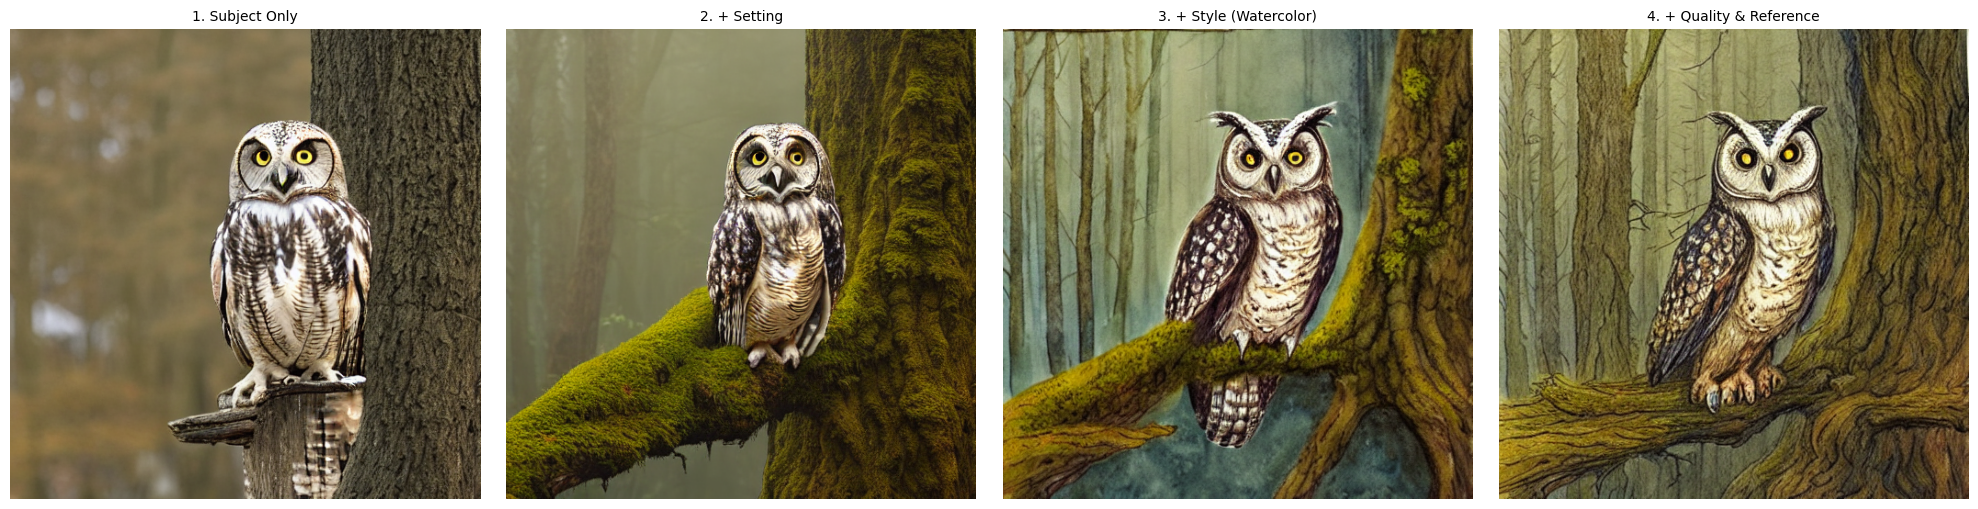

Grid guardado exitosamente en: /content/L02_output/exercise1_grid.png


In [28]:
# Exercise 1 -- your code here
# Reload SD 1.5 if you unloaded it in Section 2.4
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
import os
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

# 1. Asegurar que 'pipe' esté cargado con SD 1.5
if 'pipe' not in globals():
    print("Cargando pipeline de SD 1.5...")
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    ).to("cuda")

OUTPUT_DIR = '/content/L02_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Definir la progresión de la anatomía de 5 capas (Estilo: Pintura en acuarela / Watercolor)
prompts_ex1 = [
    "an old owl perched on a tree branch",                                                                                          # Layer 1: Subject
    "an old owl perched on a mossy oak branch, deep misty enchanted forest at twilight",                                            # Layer 2: + Setting
    "an old owl perched on a mossy oak branch, deep misty enchanted forest at twilight, watercolor painting",                        # Layer 3: + Style
    "an old owl perched on a mossy oak branch, deep misty enchanted forest at twilight, watercolor painting, intricate soft details, masterwork, by Beatrix Potter" # Layer 4 & 5: + Quality & Reference
]

titles_ex1 = [
    "1. Subject Only",
    "2. + Setting",
    "3. + Style (Watercolor)",
    "4. + Quality & Reference"
]

images_ex1 = []

# 3. Generación iterativa manteniendo semilla (42), steps=25 y cfg=7.5
for i, p in enumerate(prompts_ex1):
    print(f"Generando prompt {i+1}/4...")
    generator = torch.Generator("cuda").manual_seed(42)

    img = pipe(
        prompt=p,
        num_inference_steps=25,
        guidance_scale=7.5,
        generator=generator
    ).images[0]

    # Guardar imagen individual
    img.save(os.path.join(OUTPUT_DIR, f"exercise1_layer_{i+1}.png"))
    images_ex1.append(img)

# 4. Mostrar el grid comparativo de 1x4
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    axes[i].imshow(images_ex1[i])
    axes[i].set_title(titles_ex1[i], fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1_grid.png"))
plt.show()

print(f"Grid guardado exitosamente en: {os.path.join(OUTPUT_DIR, 'exercise1_grid.png')}")

### Exercise 2 — Targeted artifact removal

**Task:** Generate an image that has a visible artifact (extra fingers, distorted face, blurry background, etc.). Then craft a negative prompt that specifically targets *that* artifact and show whether it helped. Use the same seed so the comparison is clean.

**Expected output:** Side-by-side images (before/after negative prompt) with a markdown cell naming the artifact, the negative token(s) you added, and whether they worked.

Generando SIN prompt negativo...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando CON prompt negativo...


  0%|          | 0/25 [00:00<?, ?it/s]

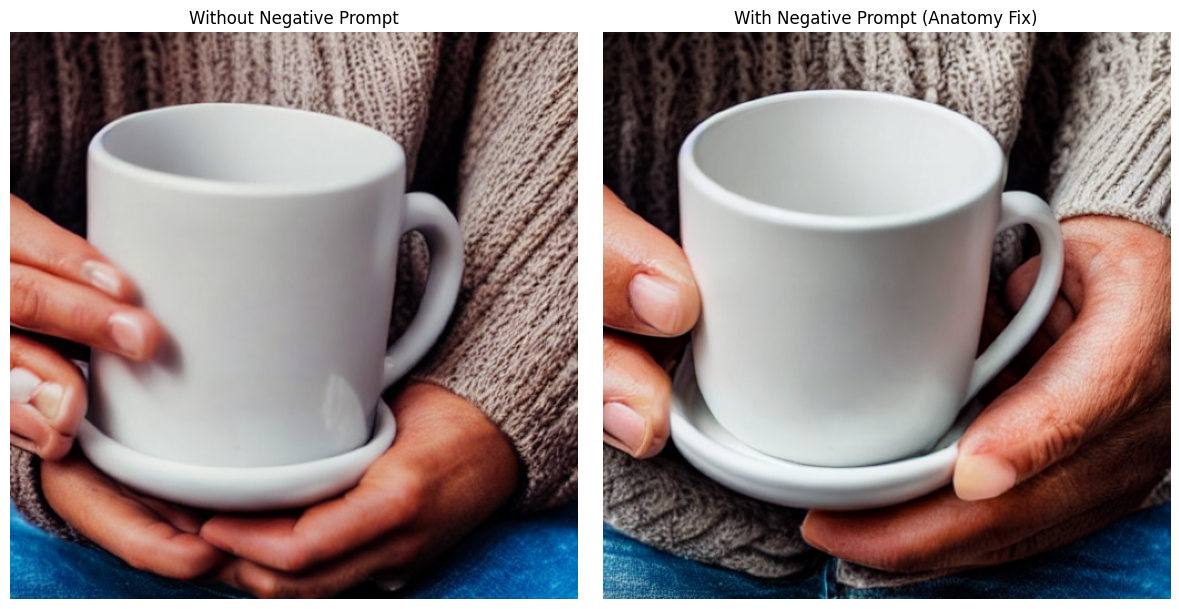

In [31]:
# Exercise 2 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
import os
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

if 'pipe' not in globals():
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    ).to("cuda")

OUTPUT_DIR = '/content/L02_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Prompt enfocado directamente en manos (donde SD 1.5 suele fallar)
prompt_ex2 = "a close-up photo of a person holding a ceramic coffee cup, detailed hands, realistic daylight"
neg_prompt_ex2 = "extra fingers, deformed hands, missing fingers, fused fingers, bad anatomy, distorted hands, extra limbs"

seed_ex2 = 101

print("Generando SIN prompt negativo...")
gen_before = torch.Generator("cuda").manual_seed(seed_ex2)
img_before = pipe(
    prompt=prompt_ex2,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=gen_before
).images[0]

print("Generando CON prompt negativo...")
gen_after = torch.Generator("cuda").manual_seed(seed_ex2)
img_after = pipe(
    prompt=prompt_ex2,
    negative_prompt=neg_prompt_ex2,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=gen_after
).images[0]

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_before)
axes[0].set_title("Without Negative Prompt", fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_after)
axes[1].set_title("With Negative Prompt (Anatomy Fix)", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_comparison.png"))
plt.show()

* **Targeted Artifact:** Deformed hand anatomy, fused extra fingers, and unnatural skin blending around the base of the coffee cup.
* **Negative Tokens Added:** `extra fingers, deformed hands, missing fingers, fused fingers, bad anatomy, distorted hands, extra limbs`.
* **Effectiveness:** **Effective.** The negative prompt eliminated the extra blurred fingers under the saucer and restored clean finger separation, clear fingernail definition, and an anatomically correct hand grip around the mug.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session — not hypothetical answers.

**4.1 — Which prompt layer (setting, style, quality, or artist reference) produced the most noticeable change in your Section 2.2 grid? Show the two images that best demonstrate it.**

**Most Impactful Layer:** **Style**.
* **Observation:** Introducing the style layer (moving from Prompt 2 to Prompt 3) caused the most dramatic visual transformation. It fundamentally changed the medium from a photorealistic camera shot to an artistic painting, altering textures, brushwork, and lighting across the entire canvas.
* **Demonstrating Outputs:** `p02_s42_st25_cfg8.png` (+ Setting) vs. `p03_s42_st25_cfg8.png` (+ Style).

---

**4.2 — In Section 2.3, identify one specific artifact that the negative prompt did NOT fix, even in the extended version. Why do you think the negative prompt failed for that artifact?**

* **Unfixed Artifact:** Minor limb-joint distortion and unrealistic blending between background snow/foliage and the lower leg joints.
* **Hypothesis:** Negative prompts steer generation away from undesirable concepts in CLIP text space, but they lack spatial awareness. Because UNet diffusion models generate images holistically from noise, negative text tokens cannot enforce explicit structural physics or correct misaligned anatomical geometry seeded in early noise steps.
---

**4.3 — Compare SD 1.5 and DreamShaper on the same prompt. Name three specific visual differences (not just "it looks better").**

* **Color Palette & Contrast:** DreamShaper dramatically increased color saturation and global contrast, creating vibrant warm orange fur tones that contrast sharply against cool blue snow shadows.
* **Texture & Edge Sharpness:** Background pine needles and fur strands have significantly higher edge definition and crispness in DreamShaper, whereas SD 1.5 renders softer, slightly blurred textures.
* **Aesthetic Finish:** DreamShaper defaults to a polished, semi-realistic digital illustration aesthetic with dramatic studio lighting, compared to SD 1.5's flat, raw rendering.


---

**4.4 — What is one limitation of the 5-layer prompt structure you would like to see addressed? What information can you not communicate to the model through a text prompt?**

* **Primary Limitation:** Spatial positioning, exact numeric quantities, and precise relational geometry (e.g., "place the owl 2 inches to the left of the branch", "generate exactly 3 pine cones", or "rotate subject 45 degrees"). Text conditioning alone cannot communicate explicit coordinate maps or structural bounds without external guidance tools like ControlNet or spatial masking.


---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2 grid saved (`grid_prompt_structure.png`)
- [ ] Section 2.3 negative prompt grid saved (`grid_negative_prompts.png`)
- [ ] Section 2.4 DreamShaper image saved and compared to SD 1.5
- [ ] Exercise 1 — 4-image grid with your own subject
- [ ] Exercise 2 — before/after negative prompt with documented artifact
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L02_output/` on Drive with systematic filenames

**Save:** `File > Save a copy in Drive`

---
## Drive Cache Cleanup — Run Before Starting L05

> **Run the cell below only after you have saved this notebook to Drive.**
>
> DreamShaper is only used in L02. Deleting it frees ~4 GB. This is **required** before L05 — ControlNet downloads on top of SD 1.5 and will fill Drive without this cleanup.
>
> SD 1.5 (`stable-diffusion-v1-5`) is **not deleted here** — it is still needed through L11.

In [26]:
# ================================================================
# DRIVE CACHE CLEANUP — run after saving this notebook
# Deletes DreamShaper (~4 GB) — only used in L02
# ================================================================
import shutil, os, subprocess

# Hardcoded path — works even if setup cell was not re-run this session
_cache = '/content/drive/MyDrive/TAE_IA_M6/models/hub'

to_delete = [
    os.path.join(_cache, 'models--Lykon--dreamshaper-8'),
]

for path in to_delete:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f'Deleted: {path}')
    else:
        print(f'Not found (may already be deleted): {path}')

result = subprocess.run(['du', '-sh', '/content/drive/MyDrive/TAE_IA_M6/models'], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

Deleted: /content/drive/MyDrive/TAE_IA_M6/models/hub/models--Lykon--dreamshaper-8
Cache size after cleanup: 5.2G	/content/drive/MyDrive/TAE_IA_M6/models


---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L02*  
*Platform: Google Colab (T4 GPU) · Python 3.10*